In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/medical-deepfakes-lung-cancer/Response EXP2 - Reviewer 3_instances.csv
/kaggle/input/medical-deepfakes-lung-cancer/Response EXP2 - Reviewer 2_patients.csv
/kaggle/input/medical-deepfakes-lung-cancer/Response EXP1 - Reviewer 3_instances.csv
/kaggle/input/medical-deepfakes-lung-cancer/Response EXP1 - Reviewer 2_instances.csv
/kaggle/input/medical-deepfakes-lung-cancer/Response EXP1 - Reviewer 3_patients.csv
/kaggle/input/medical-deepfakes-lung-cancer/labels_exp2.csv
/kaggle/input/medical-deepfakes-lung-cancer/Response EXP2 - Reviewer 2_instances.csv
/kaggle/input/medical-deepfakes-lung-cancer/Response EXP2 - Reviewer 1_patients.csv
/kaggle/input/medical-deepfakes-lung-cancer/labels_exp1.csv
/kaggle/input/medical-deepfakes-lung-cancer/Response EXP1 - Reviewer 1_instances.csv
/kaggle/input/medical-deepfakes-lung-cancer/Response EXP2 - Reviewer 1_instances.csv
/kaggle/input/medical-deepfakes-lung-cancer/Response EXP1 - Reviewer 2_patients.csv
/kaggle/input/medical-deepfakes-lu

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [3]:
import os
import pydicom
import cv2
import numpy as np
from tqdm import tqdm

# Input and output directories
dcm_root_dir = "/kaggle/input/medical-deepfakes-lung-cancer/CT_Scans"  # Update with actual path
jpg_root_dir = "/kaggle/working/dataset_jpg"  # Output directory for JPEG images

# Function to convert DICOM to JPG
def convert_dcm_to_jpg(dcm_root, jpg_root):
    for exp_dir in ["EXP1_blind", "EXP2_open"]:  # Loop through both experiment directories
        dcm_exp_path = os.path.join(dcm_root, exp_dir)
        jpg_exp_path = os.path.join(jpg_root, exp_dir)
        os.makedirs(jpg_exp_path, exist_ok=True)
        
        # Traverse all patient directories
        for patient_folder in os.listdir(dcm_exp_path):
            patient_dcm_path = os.path.join(dcm_exp_path, patient_folder)
            patient_jpg_path = os.path.join(jpg_exp_path, patient_folder)
            os.makedirs(patient_jpg_path, exist_ok=True)

            for file in tqdm(os.listdir(patient_dcm_path), desc=f"Converting {exp_dir}/{patient_folder}"):
                if file.endswith(".dcm"):
                    dcm_file = os.path.join(patient_dcm_path, file)
                    jpg_file = os.path.join(patient_jpg_path, file.replace(".dcm", ".jpg"))

                    try:
                        # Read DICOM file
                        dicom_data = pydicom.dcmread(dcm_file)
                        image = dicom_data.pixel_array  # Extract pixel data
                        
                        # Normalize and convert to 8-bit grayscale
                        image = (image - np.min(image)) / (np.max(image) - np.min(image)) * 255
                        image = image.astype(np.uint8)
                        
                        # Save as JPEG
                        cv2.imwrite(jpg_file, image)

                    except Exception as e:
                        print(f"Error converting {dcm_file}: {e}")

# Run the conversion
convert_dcm_to_jpg(dcm_root_dir, jpg_root_dir)

print("DICOM to JPEG conversion complete!")

Converting EXP1_blind/3025:  21%|██        | 48/233 [00:00<00:01, 112.93it/s]<ipython-input-3-eec97310ae9d>:35: RuntimeWarning: overflow encountered in scalar subtract
  image = (image - np.min(image)) / (np.max(image) - np.min(image)) * 255
Converting EXP2_open/2366: 100%|██████████| 133/133 [00:01<00:00, 100.96it/s]

DICOM to JPEG conversion complete!


In [6]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Base dataset directory
dataset_path = '/kaggle/working/dataset_jpg'

# Output directories
output_dir = '/kaggle/working/split_dataset'
train_dir = os.path.join(output_dir, 'train')
valid_dir = os.path.join(output_dir, 'valid')
test_dir = os.path.join(output_dir, 'test')

# Create output directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(valid_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Train, Test, Validation split ratios
train_ratio = 0.7
valid_ratio = 0.15
test_ratio = 0.15

# Iterate over main classes (EXP1_blind, EXP2_open)
for class_folder in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_folder)
    
    if os.path.isdir(class_path):
        # Iterate over subdirectories (e.g., 1067, 1068, ...)
        for sub_folder in os.listdir(class_path):
            sub_folder_path = os.path.join(class_path, sub_folder)
            
            if os.path.isdir(sub_folder_path):
                images = os.listdir(sub_folder_path)
                
                # Train-Test-Validation split
                train_imgs, temp_imgs = train_test_split(images, test_size=(1 - train_ratio), random_state=42)
                valid_imgs, test_imgs = train_test_split(temp_imgs, test_size=test_ratio / (test_ratio + valid_ratio), random_state=42)
                
                # Copy images to respective directories
                for img in train_imgs:
                    src = os.path.join(sub_folder_path, img)
                    dst = os.path.join(train_dir, class_folder, sub_folder)
                    os.makedirs(dst, exist_ok=True)
                    shutil.copy(src, dst)
                
                for img in valid_imgs:
                    src = os.path.join(sub_folder_path, img)
                    dst = os.path.join(valid_dir, class_folder, sub_folder)
                    os.makedirs(dst, exist_ok=True)
                    shutil.copy(src, dst)
                
                for img in test_imgs:
                    src = os.path.join(sub_folder_path, img)
                    dst = os.path.join(test_dir, class_folder, sub_folder)
                    os.makedirs(dst, exist_ok=True)
                    shutil.copy(src, dst)

print("Dataset successfully split into train, validation, and test sets.")


Dataset successfully split into train, validation, and test sets.


In [10]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Paths to the converted dataset
dataset_dir = "/kaggle/working/split_dataset"  # Update this path
train_dir = os.path.join(dataset_dir, "train")  # Organize dataset into train/test
test_dir = os.path.join(dataset_dir, "test")

# Image Parameters
IMG_SIZE = 224  # Image resolution
BATCH_SIZE = 32

# Data Augmentation & Preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    validation_split=0.2  # Split 80% train, 20% validation
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification: Real vs Fake
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_data, validation_data=val_data, epochs=10)

# Test the model
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_loss, test_acc = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc:.2f}")

# Save the model
model.save("deepfake_detection_model.h5")

Found 12696 images belonging to 2 classes.
Found 3174 images belonging to 2 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


397/397 ━━━━━━━━━━━━━━━━━━━━ 185s 441ms/step - accuracy: 0.7650 - loss: 0.5461 - val_accuracy: 0.7492 - val_loss: 0.5514
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 170s 421ms/step - accuracy: 0.7817 - loss: 0.5171 - val_accuracy: 0.7583 - val_loss: 0.5188
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 170s 421ms/step - accuracy: 0.7874 - loss: 0.4805 - val_accuracy: 0.7527 - val_loss: 0.5281
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 168s 418ms/step - accuracy: 0.7978 - loss: 0.4524 - val_accuracy: 0.7798 - val_loss: 0.5156
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 170s 423ms/step - accuracy: 0.8208 - loss: 0.4306 - val_accuracy: 0.7782 - val_loss: 0.5226
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 170s 421ms/step - accuracy: 0.8264 - loss: 0.4012 - val_accuracy: 0.7883 - val_loss: 0.5066
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 168s 417ms/step - accuracy: 0.8335 - loss: 0.3957 - val_accuracy: 0.7826 - val_loss: 0.4923
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 170s 423ms/step - accuracy: 0.8402 - loss: 0.38

In [11]:
# Image preprocessing and augmentation
IMG_SIZE = 224  # Resize images
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


Found 12696 images belonging to 2 classes.
Found 3174 images belonging to 2 classes.


In [12]:
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np

# Paths
model_path = 'deepfake_detection_model.h5'  # Path to your trained model
test_dir = '/kaggle/working/split_dataset/test'  # Path to the test dataset

# Load the model
model = load_model(model_path)

# Image preprocessing parameters
img_size = (224, 224)  # Change this to the input size of your model

# Class labels (Update based on your dataset)
class_labels = ['EXP1_blind', 'EXP2_open']

# Perform inference
def predict_image(image_path):
    # Load and preprocess the image
    img = load_img(image_path, target_size=img_size)
    img_array = img_to_array(img) / 255.0  # Normalize to [0, 1]
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Perform prediction
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)[0]
    confidence = predictions[0][predicted_class]

    return class_labels[predicted_class], confidence

# Iterate over test images and make predictions
results = []
for class_folder in os.listdir(test_dir):
    class_folder_path = os.path.join(test_dir, class_folder)
    if os.path.isdir(class_folder_path):
        for sub_folder in os.listdir(class_folder_path):
            sub_folder_path = os.path.join(class_folder_path, sub_folder)
            if os.path.isdir(sub_folder_path):
                for img_file in os.listdir(sub_folder_path):
                    img_path = os.path.join(sub_folder_path, img_file)
                    predicted_class, confidence = predict_image(img_path)
                    results.append({
                        "image": img_file,
                        "actual_class": class_folder,
                        "predicted_class": predicted_class,
                        "confidence": confidence
                    })

# Display results
for result in results:
    print(f"Image: {result['image']}, Actual: {result['actual_class']}, "
          f"Predicted: {result['predicted_class']}, Confidence: {result['confidence']:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━

Found 3465 images belonging to 2 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.5350 - loss: 0.7652
Test Loss: 0.631075382232666
Test Accuracy: 0.6063492298126221
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step


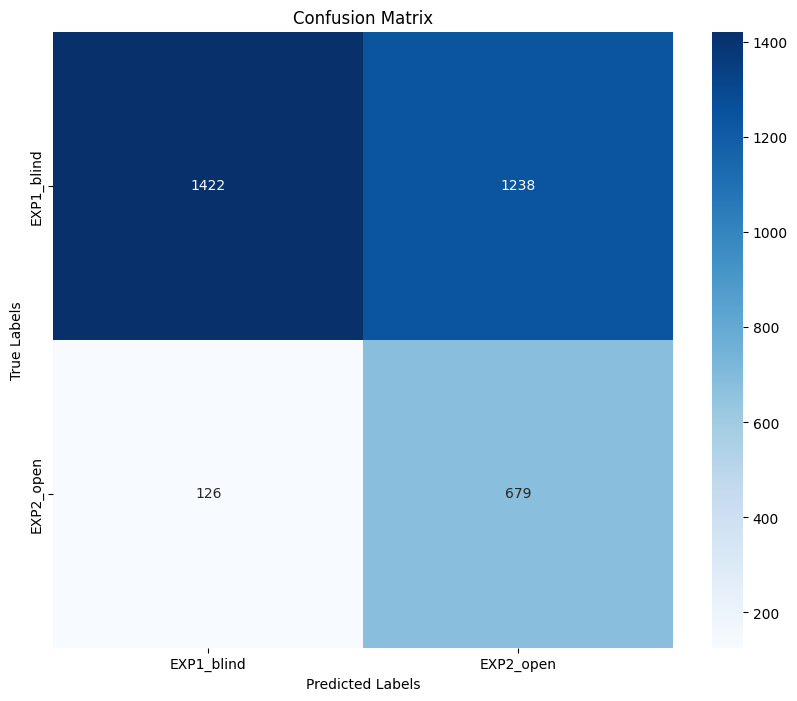


Classification Report:

              precision    recall  f1-score   support

  EXP1_blind       0.92      0.53      0.68      2660
   EXP2_open       0.35      0.84      0.50       805

    accuracy                           0.61      3465
   macro avg       0.64      0.69      0.59      3465
weighted avg       0.79      0.61      0.63      3465



In [18]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the trained model
model = load_model('deepfake_detection_model.h5')

# Define image size and batch size
img_size = (224, 224)
batch_size = 32

# Prepare the test data generator
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_generator = test_datagen.flow_from_directory(
    '/kaggle/working/split_dataset/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',  # For binary classification
    shuffle=False
)

# Evaluate the model
loss, accuracy = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

# Predict classes
test_generator.reset()
predictions = (model.predict(test_generator, verbose=1) > 0.5).astype("int32")

# Confusion Matrix
conf_matrix = confusion_matrix(test_generator.classes, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Classification Report
report = classification_report(test_generator.classes, predictions,
                               target_names=test_generator.class_indices.keys())
print("\nClassification Report:\n")
print(report)
